In [1]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.cluster import KMeans

In [2]:
train = pd.read_csv('../data/processed/train.csv')
val = pd.read_csv('../data/processed/val.csv')
test = pd.read_csv('../data/processed/test.csv')

In [3]:
print(train.columns.tolist())

['ID', 'Year_Birth', 'Education', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Response', 'Age', 'Total_Children', 'Total_Spend', 'Wine_Ratio', 'Meat_Ratio', 'Total_Purchases', 'Web_Purchase_Ratio', 'Spend_per_Purchase', 'Education_Grouped_Postgraduate', 'Education_Grouped_Undergraduate', 'Marital_Status_Married', 'Marital_Status_Single', 'Marital_Status_Together', 'Marital_Status_Widow', 'Customer_Tenure']


In [4]:
# Data sanity checks before scaling
mnt_cols = ['MntWines', 'MntFruits', 'MntMeatProducts',
            'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

# Channel purchase counts only; NumDealsPurchases may overlap with channels.
purchase_cols = ['NumWebPurchases', 'NumStorePurchases',
                 'NumCatalogPurchases']

# zero spend & zero purchases calculations: flags how many customers will produce a division-by-zero (divide by purchases/spend), to understand why a NaN or inf showing up later 

for name, df in [('train', train), ('val', val), ('test', test)]:
    total_spend = df[mnt_cols].sum(axis=1)
    total_purchases = df[purchase_cols].sum(axis=1)
    income_nans = df['Income'].isna().sum()
    zero_spend = (total_spend == 0).sum()
    zero_purchases = (total_purchases == 0).sum()
    n_rows = len(df)
    print(f'{name}: Income NaNs={income_nans}, '
          f'zero spend={zero_spend} ({zero_spend / n_rows:.1%}), '
          f'zero purchases={zero_purchases} ({zero_purchases / n_rows:.1%})')


train: Income NaNs=0, zero spend=0 (0.0%), zero purchases=4 (0.3%)
val: Income NaNs=0, zero spend=0 (0.0%), zero purchases=1 (0.3%)
test: Income NaNs=0, zero spend=0 (0.0%), zero purchases=1 (0.3%)


In [5]:
# Preprocessing (scaling, encoding - fit on train ONLY, apply to val/test)
from sklearn.preprocessing import StandardScaler

# the exact 10-column subset that will actually go into KMeans
feature_cols = ['Income', 'Total_Spend', 'Wine_Ratio', 'Meat_Ratio',
                 'Web_Purchase_Ratio', 'Spend_per_Purchase', 'Age',
                 'Total_Children', 'Customer_Tenure', 'Recency']

# raises any missing values
for name, df in [('train', train), ('val', val), ('test', test)]:
    missing = df[feature_cols].isna().sum()
    if missing.any():
        raise ValueError(f'{name} has NaNs before scaling: {missing[missing > 0].to_dict()}')

# StandardScaler computes and stores mean and standard deviation per column
# .fit_transform() computes mean/std from train only, stores them inside scaler, then applies that formula to train itself.
# .transform() reuses the train-derived mean/std and applies the same formula to val/test
scaler = StandardScaler()
X_train = scaler.fit_transform(train[feature_cols])
X_val = scaler.transform(val[feature_cols])
X_test = scaler.transform(test[feature_cols])

# Print 15 sample rows using only the final 10 feature columns
print('Final 10 feature columns:')
print(feature_cols)

print('\n15 sample training rows with final feature columns only:')
print(train[feature_cols].sample(n=15, random_state=42).to_string(index=False))

Final 10 feature columns:
['Income', 'Total_Spend', 'Wine_Ratio', 'Meat_Ratio', 'Web_Purchase_Ratio', 'Spend_per_Purchase', 'Age', 'Total_Children', 'Customer_Tenure', 'Recency']

15 sample training rows with final feature columns only:
  Income  Total_Spend  Wine_Ratio  Meat_Ratio  Web_Purchase_Ratio  Spend_per_Purchase  Age  Total_Children  Customer_Tenure  Recency
 66426.0         1377    0.757444    0.070443            0.150000           68.850000   53               1              270       14
 86580.0          746    0.713137    0.170241            0.363636           67.818182   31               0              487       72
 19510.0           30    0.300000    0.233333            0.166667            5.000000   29               2              298       63
160803.0         1717    0.032033    0.944671            0.000000           39.022727   32               0              694       21
 36778.0           77    0.376623    0.441558            0.333333            8.555556   46        

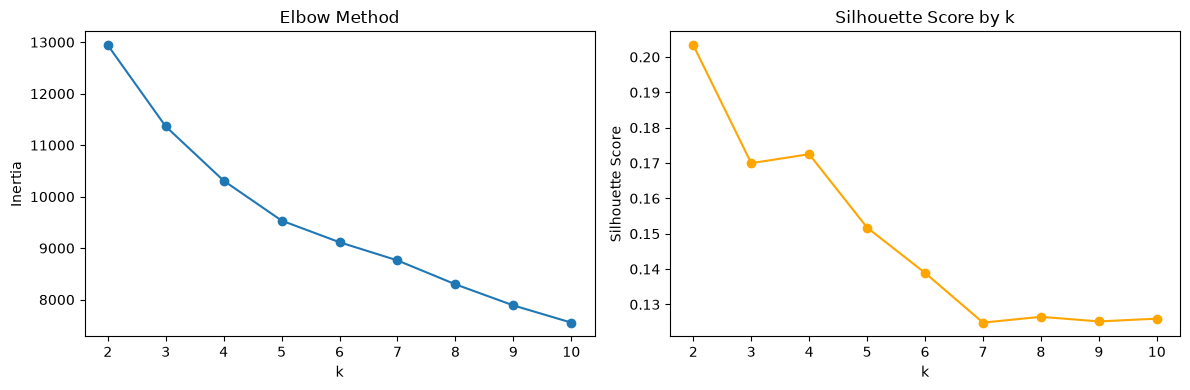

In [6]:
# Elbow method + silhouette score to choose k
from sklearn.metrics import silhouette_score

# elbow method: how far, on average, points are from their own cluster's center. Lower inertia means tighter, more compact clusters.
# plot inertia against k and look for the elbow (the point where the line stops dropping steeply and starts flattening out)

# silhouette score: how well-separated the clusters actually are (how close that point is to others in its own cluster & how close it is to points in the nearest other cluster)
# Higher is better!

k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_train)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_train, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(list(k_range), silhouette_scores, marker='o', color='orange')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by k')

plt.tight_layout()
plt.show()

In [7]:
# Fit final KMeans with chosen k
k = 4  # <-- set based on elbow + silhouette results above
model = KMeans(n_clusters=k, random_state=42, n_init=10)
model.fit(X_train)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](4, 10)","[[ 0

In [8]:
# Predict on val/test + cluster stability check

# Cluster assignments for all splits
train_labels = model.labels_
val_labels = model.predict(X_val)
test_labels = model.predict(X_test)

train['Cluster'] = train_labels
val['Cluster'] = val_labels
test['Cluster'] = test_labels

# Stability check: does each split get a similar-sized spread of clusters?
from sklearn.metrics import silhouette_score

for name, labels, X in [('train', train_labels, X_train),
                         ('val', val_labels, X_val),
                         ('test', test_labels, X_test)]:
    sizes = pd.Series(labels).value_counts(normalize=True).sort_index()
    sil = silhouette_score(X, labels)
    print(f'{name}: cluster proportions={sizes.round(3).to_dict()}, silhouette={sil:.3f}')

train: cluster proportions={0: 0.25, 1: 0.353, 2: 0.396, 3: 0.001}, silhouette=0.172
val: cluster proportions={0: 0.259, 1: 0.336, 2: 0.405}, silhouette=0.161
test: cluster proportions={0: 0.289, 1: 0.336, 2: 0.375}, silhouette=0.182


In [9]:
# Per-cluster profiling table

profile_cols = ['Income', 'Total_Spend', 'Age', 'Total_Children',
                 'Customer_Tenure', 'Recency']
# whether a customer accepted each of the company's past marketing campaigns.
campaign_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
                  'AcceptedCmp4', 'AcceptedCmp5', 'Response']

# Combine splits for one full-sample profile (labels already assigned above)
all_data = pd.concat([train, val, test], ignore_index=True)

# customers .groupby their respective clusters 
# n_cust: no. cust per cluster
cluster_profile = all_data.groupby('Cluster')[profile_cols].mean().round(1)
cluster_profile['n_customers'] = all_data.groupby('Cluster').size()
cluster_profile['acceptance_rate'] = all_data.groupby('Cluster')[campaign_cols].mean().mean(axis=1).round(3)

cluster_profile

,Income,Total_Spend,Age,Total_Children,Customer_Tenure,Recency,n_customers,acceptance_rate
Cluster,,,,,,,,
0,77406.0,1394.0,45.6,0.2,364.6,51.5,576,0.162
1,32418.6,138.0,38.8,1.0,352.1,51.0,778,0.033
2,53246.8,502.4,50.4,1.3,347.8,45.9,882,0.054
3,50943.0,1679.0,36.0,0.0,686.0,53.0,1,0.167


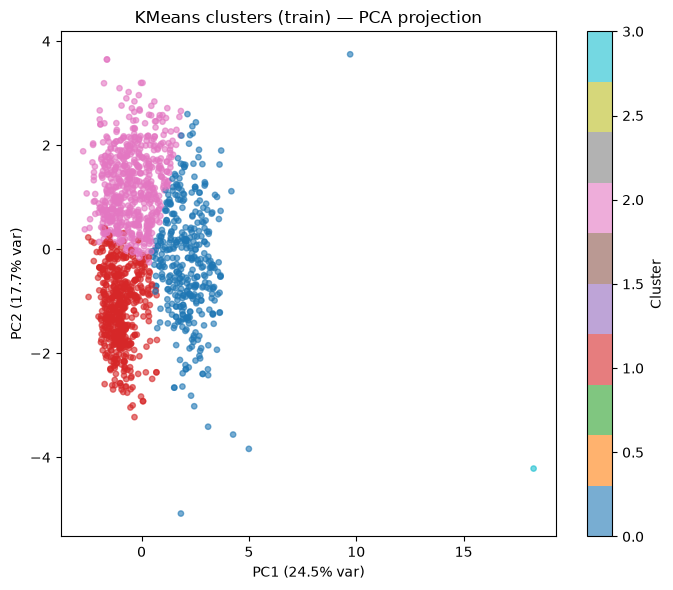

In [10]:
# PCA 2D visualization

from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train)   # fit on train only — no leakage
X_val_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)

fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1],
                      c=train_labels, cmap='tab10', alpha=0.6, s=15)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
ax.set_title('KMeans clusters (train) — PCA projection')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

In [11]:
# Cell 6: Save the final model
joblib.dump(model, '../models/final_model.sav')
joblib.dump(scaler, '../models/scaler.sav')

['../models/scaler.sav']